# Perturbation Detection via the Alpha-Transform

**Can we detect and reconstruct an unknown perturbation to a known system, using only fixed-point analysis and the alpha-transform?**

The experiment: a mass on a known spring $k_1$ experiences an additional, unknown potential $V_\text{pert}(x)$. We observe the system's behavior, model it with just $k_1$, and ask: what does the alpha-transform needed to correct the model tell us about the perturbation?

**Roadmap:**

| § | Section | Question |
|---|---------|----------|
| 1 | Single spring baseline | Does our fitting pipeline recover $k_1$ from trajectory data? |
| 2 | Two-spring system | What does the "true" system look like? |
| 3 | Model failure | Where does the single-spring prediction break? |
| 4 | Relaxation maps + FPA | How do we cast this as a fixed-point problem? |
| 5 | Alpha-transform detection | Can constant $\alpha$ detect the perturbation strength? |
| 6 | Displaced spring | Can $\alpha(x)$ detect position AND strength? |
| 7 | Nonlinear perturbation | Can $\alpha(x)$ reveal the *functional form* of $V_\text{pert}$? |
| 8 | Blind reconstruction | Can we reconstruct $V_\text{pert}(x)$ from $\alpha(x)$ alone? |
| 9 | Assessment | What actually has power here? |

In [1]:
import sys, importlib
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, '..')
import petrification.oscillators as osc
importlib.reload(osc)

from petrification.oscillators import (
    hooke_force, hooke_potential, quartic_force, quartic_potential,
    combine_forces, simulate, find_peaks, fit_damped_sinusoid,
    extract_spring_constant, relaxation_map, measure_alpha_profile,
    infer_perturbation,
)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
np.set_printoptions(precision=6)

In [2]:
# --- Physical parameters (shared across all experiments) ---
m     = 1.0      # mass
gamma = 0.5      # damping coefficient
k1    = 10.0     # dominant spring constant
k2    = 1.0      # perturbation spring (10% of k1)
x0    = 2.0      # initial displacement
v0    = 0.0      # initial velocity
T     = (0, 30)  # simulation window

# Derived quantities
omega_1  = np.sqrt(k1 / m)
beta     = gamma / (2 * m)
omega_d1 = np.sqrt(k1/m - beta**2)
T_1      = 2 * np.pi / omega_d1

print(f"Model spring: k1 = {k1},  ω₁ = {omega_1:.4f},  ωd₁ = {omega_d1:.4f},  T₁ = {T_1:.4f} s")
print(f"Perturbation: k2 = {k2}  ({100*k2/k1:.0f}% of k1)")
print(f"Damping: γ = {gamma},  β = {beta},  Q ≈ {omega_1/(2*beta):.1f}")

Model spring: k1 = 10.0,  ω₁ = 3.1623,  ωd₁ = 3.1524,  T₁ = 1.9932 s
Perturbation: k2 = 1.0  (10% of k1)
Damping: γ = 0.5,  β = 0.25,  Q ≈ 6.3


## §1. Single Spring Baseline

Sanity check: simulate a mass on one spring, fit a damped sinusoid, recover $k_1$, and confirm the trajectory matches $V(x) = \tfrac{1}{2}k_1 x^2$.

Fitted parameters:
         A = +2.006279
      beta = +0.250000
   omega_d = +3.152380
       phi = -0.079140
      x_eq = +0.000000

Recovered spring constant: k_fit = 10.000000  (true k1 = 10.0)
Relative error: 4.02e-11


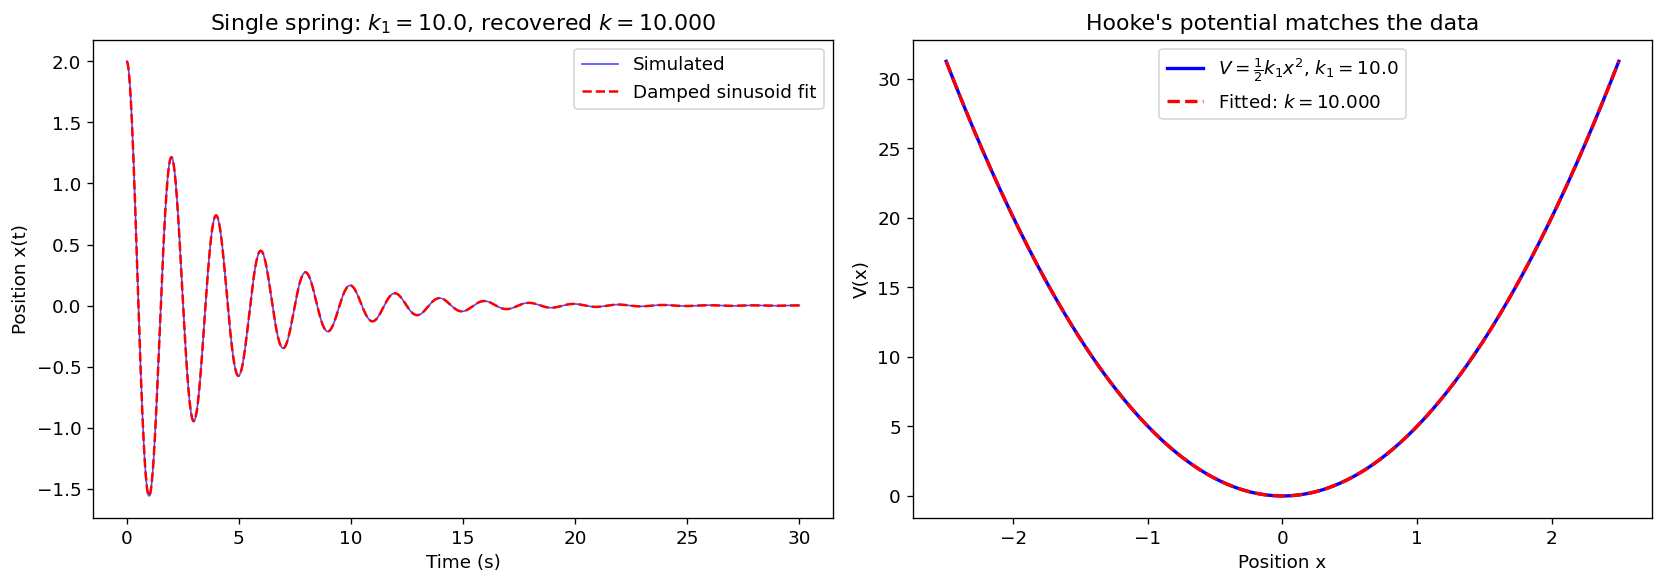

In [3]:
# --- Simulate single-spring system ---
F1 = hooke_force(k1)
V1_prime = lambda x: -F1(x)   # V'(x) = k1*x

t1, x1, v1 = simulate(V1_prime, gamma, m, x0, v0, T)

# --- Fit damped sinusoid ---
params1, x1_fit = fit_damped_sinusoid(t1, x1)
k1_recovered = extract_spring_constant(params1['omega_d'], params1['beta'], m)

print("Fitted parameters:")
for key, val in params1.items():
    print(f"  {key:>8s} = {val:+.6f}")
print(f"\nRecovered spring constant: k_fit = {k1_recovered:.6f}  (true k1 = {k1})")
print(f"Relative error: {abs(k1_recovered - k1)/k1:.2e}")

# --- Plot trajectory + fit + potential ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(t1, x1, 'b-', lw=1, alpha=0.7, label='Simulated')
ax1.plot(t1, x1_fit, 'r--', lw=1.5, label='Damped sinusoid fit')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Position x(t)')
ax1.set_title(f'Single spring: $k_1={k1}$, recovered $k={k1_recovered:.3f}$')
ax1.legend()

x_pot = np.linspace(-2.5, 2.5, 300)
ax2.plot(x_pot, hooke_potential(k1, x_pot), 'b-', lw=2, label=rf'$V = \frac{{1}}{{2}}k_1 x^2$, $k_1={k1}$')
ax2.plot(x_pot, hooke_potential(k1_recovered, x_pot), 'r--', lw=2,
         label=rf'Fitted: $k={k1_recovered:.3f}$')
ax2.set_xlabel('Position x')
ax2.set_ylabel('V(x)')
ax2.set_title("Hooke's potential matches the data")
ax2.legend()

plt.tight_layout()
plt.show()

## §2. Two-Spring System (the "True" System)

Now the real system: a mass on **two** parallel springs $k_1$ and $k_2$. The effective potential is $V_\text{true} = \tfrac{1}{2}(k_1 + k_2)x^2$.

A naive fit still returns a damped sinusoid — but with $k_\text{eff} = k_1 + k_2$. From the fit alone, we **cannot tell** whether it's one spring or two. We just see a slightly stiffer oscillator.

Two-spring system fit:
  ω_d  = 3.307189  (single-spring: 3.152380)
  β    = 0.250000  (single-spring: 0.250000)
  k_eff = 11.000000  (true: k1+k2 = 11.0)

The fit sees k_eff = 11.000. But is it one spring at 11.0, or two at 10.0+1.0?
From a single trajectory fit alone: we cannot tell.


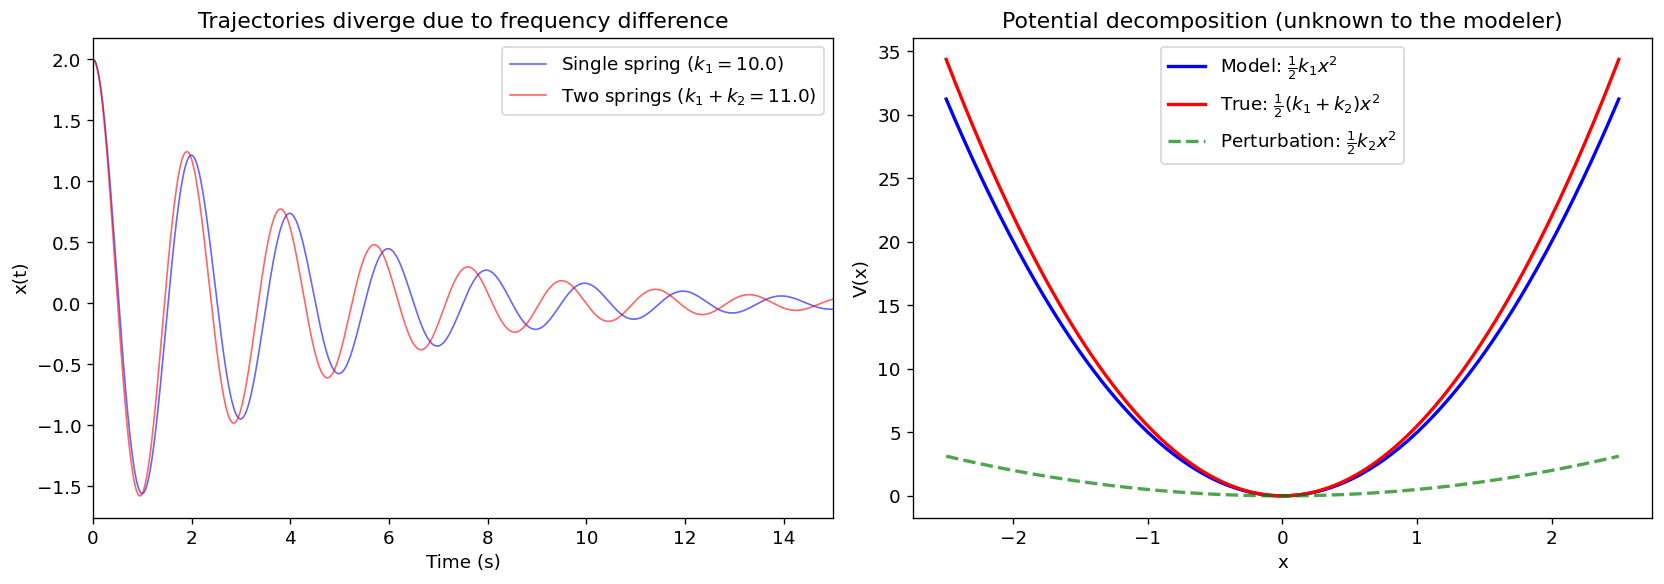

In [4]:
# --- Simulate two-spring system ---
F_true = combine_forces(hooke_force(k1), hooke_force(k2))
V_true_prime = lambda x: -F_true(x)  # V' = (k1+k2)*x

t2, x2, v2 = simulate(V_true_prime, gamma, m, x0, v0, T)

# --- Fit ---
params2, x2_fit = fit_damped_sinusoid(t2, x2)
k_eff = extract_spring_constant(params2['omega_d'], params2['beta'], m)

print("Two-spring system fit:")
print(f"  ω_d  = {params2['omega_d']:.6f}  (single-spring: {params1['omega_d']:.6f})")
print(f"  β    = {params2['beta']:.6f}  (single-spring: {params1['beta']:.6f})")
print(f"  k_eff = {k_eff:.6f}  (true: k1+k2 = {k1+k2})")
print(f"\nThe fit sees k_eff = {k_eff:.3f}. But is it one spring at {k_eff:.1f}, or two at {k1}+{k2}?")
print("From a single trajectory fit alone: we cannot tell.")

# --- Plot both trajectories and potentials ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(t1, x1, 'b-', lw=1, alpha=0.6, label=f'Single spring ($k_1={k1}$)')
ax1.plot(t2, x2, 'r-', lw=1, alpha=0.6, label=f'Two springs ($k_1+k_2={k1+k2}$)')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('x(t)')
ax1.set_title('Trajectories diverge due to frequency difference')
ax1.legend()
ax1.set_xlim(0, 15)

ax2.plot(x_pot, hooke_potential(k1, x_pot), 'b-', lw=2, label=rf'Model: $\frac{{1}}{{2}}k_1 x^2$')
ax2.plot(x_pot, hooke_potential(k1+k2, x_pot), 'r-', lw=2,
         label=rf'True: $\frac{{1}}{{2}}(k_1+k_2) x^2$')
ax2.plot(x_pot, hooke_potential(k2, x_pot), 'g--', lw=2, alpha=0.7,
         label=rf'Perturbation: $\frac{{1}}{{2}}k_2 x^2$')
ax2.set_xlabel('x')
ax2.set_ylabel('V(x)')
ax2.set_title('Potential decomposition (unknown to the modeler)')
ax2.legend()

plt.tight_layout()
plt.show()

## §3. Single-Potential Model Failure

If we only know about spring $k_1$, we predict a trajectory $x_\text{model}(t)$ — but the true system oscillates at a different frequency and decays at a different rate. The residual grows over time as the two trajectories drift out of phase.

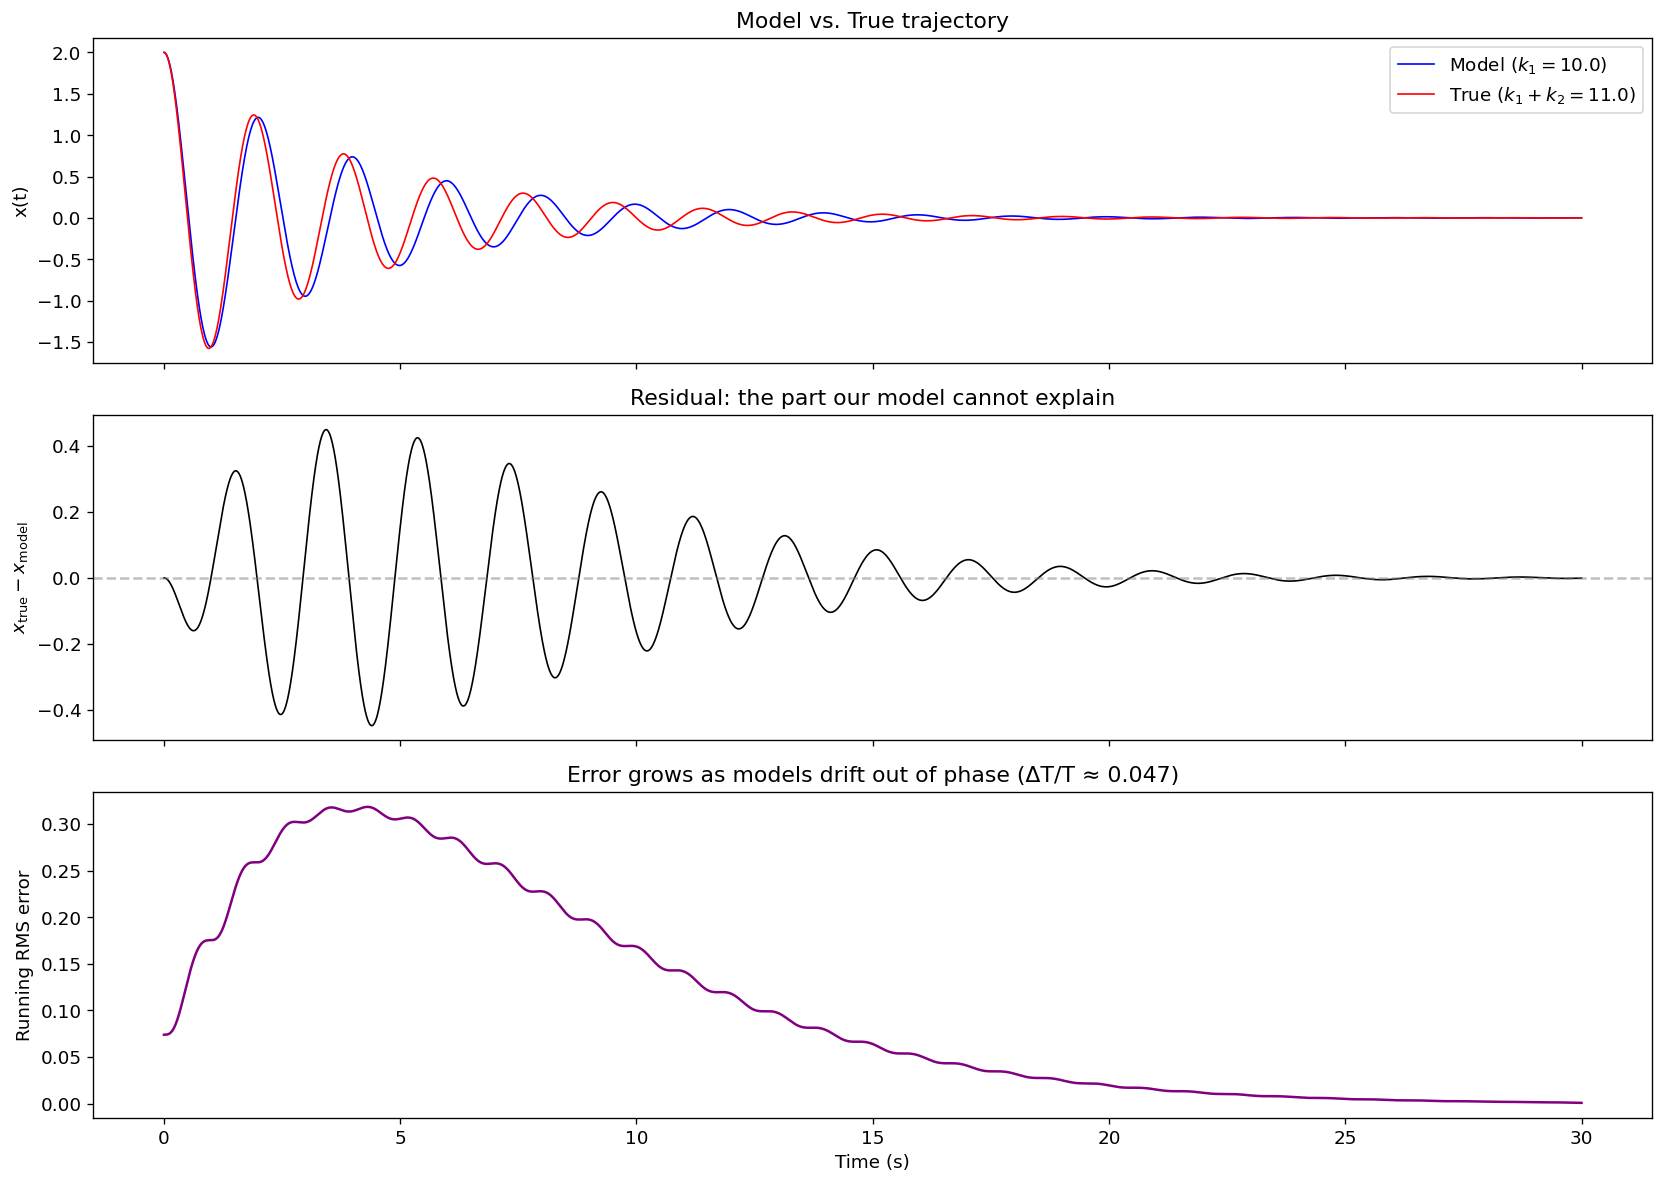

Model frequency: ωd = 3.1524  (T = 1.9932 s)
True frequency:  ωd = 3.3072  (T = 1.8999 s)
The single-spring model simply oscillates too slowly.


In [5]:
# --- Model prediction (single spring) vs true data (two springs) ---
residual = x2 - x1   # what the model CANNOT explain

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel 1: trajectories
axes[0].plot(t1, x1, 'b-', lw=1, label=f'Model ($k_1={k1}$)')
axes[0].plot(t2, x2, 'r-', lw=1, label=f'True ($k_1+k_2={k1+k2}$)')
axes[0].set_ylabel('x(t)')
axes[0].set_title('Model vs. True trajectory')
axes[0].legend()

# Panel 2: residual
axes[1].plot(t1, residual, 'k-', lw=1)
axes[1].axhline(0, color='gray', ls='--', alpha=0.5)
axes[1].set_ylabel(r'$x_\mathrm{true} - x_\mathrm{model}$')
axes[1].set_title('Residual: the part our model cannot explain')

# Panel 3: running RMS error
window = int(T_1 / 0.001)  # one period window
rms = np.sqrt(np.convolve(residual**2, np.ones(window)/window, mode='same'))
axes[2].plot(t1, rms, 'purple', lw=1.5)
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Running RMS error')
axes[2].set_title(f'Error grows as models drift out of phase (ΔT/T ≈ {abs(T_1 - 2*np.pi/np.sqrt((k1+k2)/m - beta**2))/T_1:.3f})')

plt.tight_layout()
plt.show()

# Frequency mismatch
omega_d_true = np.sqrt((k1+k2)/m - beta**2)
print(f"Model frequency: ωd = {omega_d1:.4f}  (T = {T_1:.4f} s)")
print(f"True frequency:  ωd = {omega_d_true:.4f}  (T = {2*np.pi/omega_d_true:.4f} s)")
print(f"The single-spring model simply oscillates too slowly.")

## §4. Turning to Fixed-Point Analysis: Relaxation Maps

The time-domain residual tells us *something is wrong*, but not what.

We now reframe the problem as **fixed-point iteration**. Given a potential $V(x)$, the gradient-descent relaxation map

$$f(x) \;=\; x - \eta\,V'(x)$$

has its fixed points at the equilibria of $V$ (where $V'(x)=0$). The slope at a fixed point $x^*$ is

$$f'(x^*) = 1 - \eta\,V''(x^*)$$

For two systems with different potentials, the maps differ — and the alpha-transform provides a precise bridge between them.

**Key relation:**

$$f_\text{true}(x) = x - \eta\,V'_\text{true}(x), \qquad f_\text{model}(x) = x - \eta\,V'_\text{model}(x)$$

$$\alpha(x) = \frac{f_\text{true}(x) - x}{f_\text{model}(x) - x} = \frac{V'_\text{true}(x)}{V'_\text{model}(x)} = 1 + \frac{V'_\text{pert}(x)}{V'_\text{model}(x)}$$

So $\alpha(x)$ is the **ratio of total to modeled restoring force**. From it:

$$V'_\text{pert}(x) = V'_\text{model}(x) \cdot (\alpha(x) - 1) = k_1 x \cdot (\alpha(x) - 1)$$

Model slope at x*=0:  f'(0) = 1 - η·k1 = 0.5000
True  slope at x*=0:  f'(0) = 1 - η·(k1+k2) = 0.4500
Model converges as |0.500|^n, true as |0.450|^n


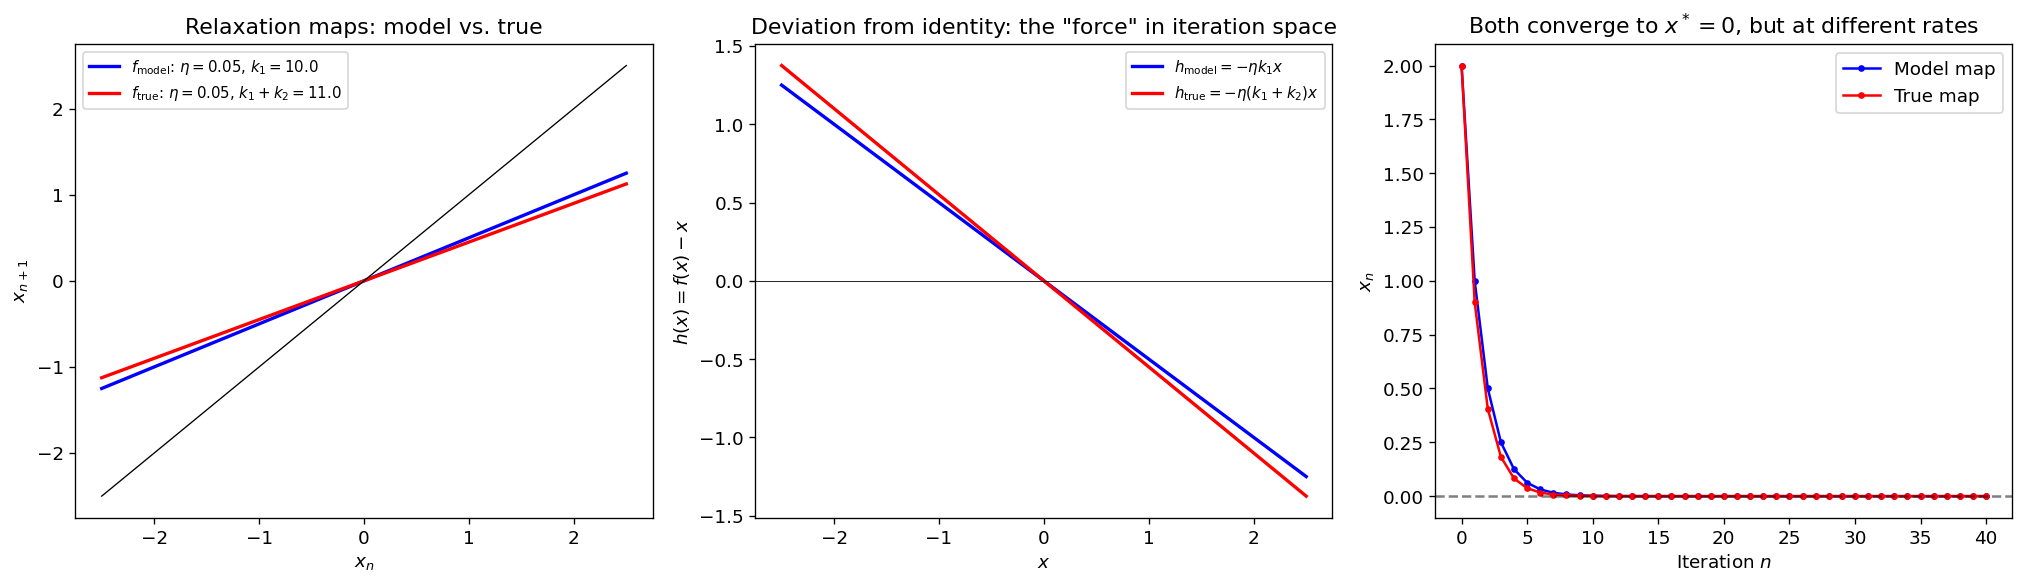

In [6]:
# --- Construct relaxation maps ---
eta = 0.05   # step size (stable when eta < 2/k for each spring)

# Model: V'_model = k1*x
V_model_prime = lambda x: k1 * np.asarray(x, dtype=float)
f_model = relaxation_map(V_model_prime, eta)

# True: V'_true = (k1+k2)*x
f_true = relaxation_map(V_true_prime, eta)

# --- Visualize the maps ---
x_map = np.linspace(-2.5, 2.5, 500)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Panel 1: The two maps
axes[0].plot(x_map, f_model(x_map), 'b-', lw=2, label=rf'$f_\mathrm{{model}}$: $\eta={eta}$, $k_1={k1}$')
axes[0].plot(x_map, f_true(x_map), 'r-', lw=2, label=rf'$f_\mathrm{{true}}$: $\eta={eta}$, $k_1+k_2={k1+k2}$')
axes[0].plot(x_map, x_map, 'k-', lw=0.8)
axes[0].set_xlabel('$x_n$')
axes[0].set_ylabel('$x_{n+1}$')
axes[0].set_title('Relaxation maps: model vs. true')
axes[0].legend(fontsize=9)

# Panel 2: h(x) = f(x) - x  (deviation from identity)
h_model = f_model(x_map) - x_map
h_true  = f_true(x_map)  - x_map
axes[1].plot(x_map, h_model, 'b-', lw=2, label=r'$h_\mathrm{model} = -\eta k_1 x$')
axes[1].plot(x_map, h_true, 'r-', lw=2, label=r'$h_\mathrm{true} = -\eta (k_1+k_2) x$')
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_xlabel('$x$')
axes[1].set_ylabel('$h(x) = f(x) - x$')
axes[1].set_title('Deviation from identity: the "force" in iteration space')
axes[1].legend(fontsize=9)

# Panel 3: Convergence comparison
n_relax = 40
x_model_traj = np.zeros(n_relax + 1)
x_true_traj  = np.zeros(n_relax + 1)
x_model_traj[0] = x0
x_true_traj[0]  = x0

for i in range(n_relax):
    x_model_traj[i+1] = f_model(x_model_traj[i])
    x_true_traj[i+1]  = f_true(x_true_traj[i])

axes[2].plot(x_model_traj, 'b-o', ms=3, label='Model map')
axes[2].plot(x_true_traj, 'r-o', ms=3, label='True map')
axes[2].axhline(0, color='k', ls='--', alpha=0.5)
axes[2].set_xlabel('Iteration $n$')
axes[2].set_ylabel('$x_n$')
axes[2].set_title('Both converge to $x^*=0$, but at different rates')
axes[2].legend()

# Slopes
lam_model = 1 - eta * k1
lam_true  = 1 - eta * (k1 + k2)
print(f"Model slope at x*=0:  f'(0) = 1 - η·k1 = {lam_model:.4f}")
print(f"True  slope at x*=0:  f'(0) = 1 - η·(k1+k2) = {lam_true:.4f}")
print(f"Model converges as |{lam_model:.3f}|^n, true as |{lam_true:.3f}|^n")

plt.tight_layout()
plt.show()

## §5. Alpha-Transform Detects the Perturbation

**The test**: Measure $\alpha(x)$ that transforms $f_\text{model} \to f_\text{true}$. For two parallel Hooke springs:

$$\alpha = \frac{V'_\text{true}}{V'_\text{model}} = \frac{(k_1+k_2)x}{k_1 x} = 1 + \frac{k_2}{k_1}$$

A **constant** $\alpha$ — and from it we immediately get $k_2 = k_1(\alpha - 1)$.

This is the simplest case: the perturbation has exactly the same functional form as the model, so one number suffices.

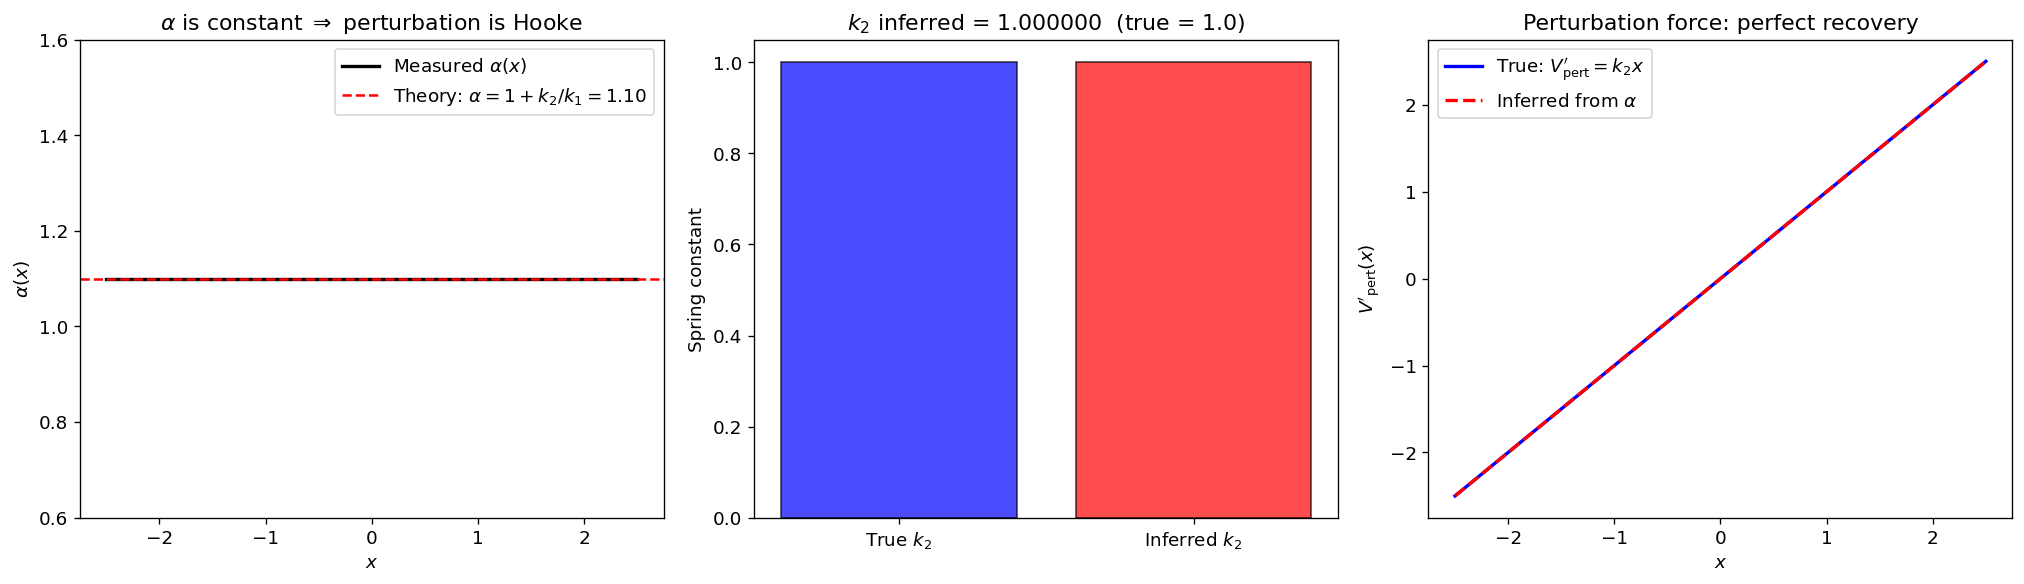

α measured  = 1.10000000
α predicted = 1.10000000
k2 inferred = 1.00000000
k2 true     = 1.00000000
Relative error: 8.88e-16


In [7]:
# --- Measure alpha profile ---
x_eval, alpha_measured = measure_alpha_profile(f_model, f_true, (-2.5, 2.5))

# Mask NaN near x=0
valid = ~np.isnan(alpha_measured)

# Theoretical prediction
alpha_theory = 1 + k2 / k1

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Panel 1: α(x) profile
axes[0].plot(x_eval[valid], alpha_measured[valid], 'k-', lw=2, label=r'Measured $\alpha(x)$')
axes[0].axhline(alpha_theory, color='r', ls='--', lw=1.5,
               label=rf'Theory: $\alpha = 1 + k_2/k_1 = {alpha_theory:.2f}$')
axes[0].set_xlabel('$x$')
axes[0].set_ylabel(r'$\alpha(x)$')
axes[0].set_title(r'$\alpha$ is constant $\Rightarrow$ perturbation is Hooke')
axes[0].legend()
axes[0].set_ylim(alpha_theory - 0.5, alpha_theory + 0.5)

# Panel 2: Infer k2
alpha_median = np.nanmedian(alpha_measured)
k2_inferred = k1 * (alpha_median - 1)

axes[1].bar(['True $k_2$', 'Inferred $k_2$'], [k2, k2_inferred],
           color=['blue', 'red'], alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Spring constant')
axes[1].set_title(f'$k_2$ inferred = {k2_inferred:.6f}  (true = {k2})')

# Panel 3: Inferred perturbation force
V_prime_pert_inferred, V_pert_inferred = infer_perturbation(k1, x_eval[valid], alpha_measured[valid])
V_prime_pert_true = k2 * x_eval[valid]
V_pert_true = hooke_potential(k2, x_eval[valid])

axes[2].plot(x_eval[valid], V_prime_pert_true, 'b-', lw=2, label=r'True: $V^\prime_\mathrm{pert} = k_2 x$')
axes[2].plot(x_eval[valid], V_prime_pert_inferred, 'r--', lw=2, label='Inferred from $\\alpha$')
axes[2].set_xlabel('$x$')
axes[2].set_ylabel(r"$V'_\mathrm{pert}(x)$")
axes[2].set_title('Perturbation force: perfect recovery')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"α measured  = {alpha_median:.8f}")
print(f"α predicted = {alpha_theory:.8f}")
print(f"k2 inferred = {k2_inferred:.8f}")
print(f"k2 true     = {k2:.8f}")
print(f"Relative error: {abs(k2_inferred - k2)/k2:.2e}")

## §6. Displaced Spring: Position-Dependent $\alpha(x)$

Now a harder test. The perturbation spring is centered at $x = d$, not at the origin:

$$V_\text{pert}(x) = \tfrac{1}{2}k_2(x - d)^2, \qquad V'_\text{pert} = k_2(x-d)$$

The alpha profile becomes **position-dependent**:

$$\alpha(x) = 1 + \frac{k_2(x-d)}{k_1 x} = 1 + \frac{k_2}{k_1} - \frac{k_2 d}{k_1 x}$$

This is an asymptotic constant plus a $1/x$ correction. From the shape of $\alpha(x)$ we can extract **both** $k_2$ and $d$:
- The asymptote as $|x| \to \infty$ gives $k_2/k_1$
- The $1/x$ coefficient gives $k_2 d / k_1$

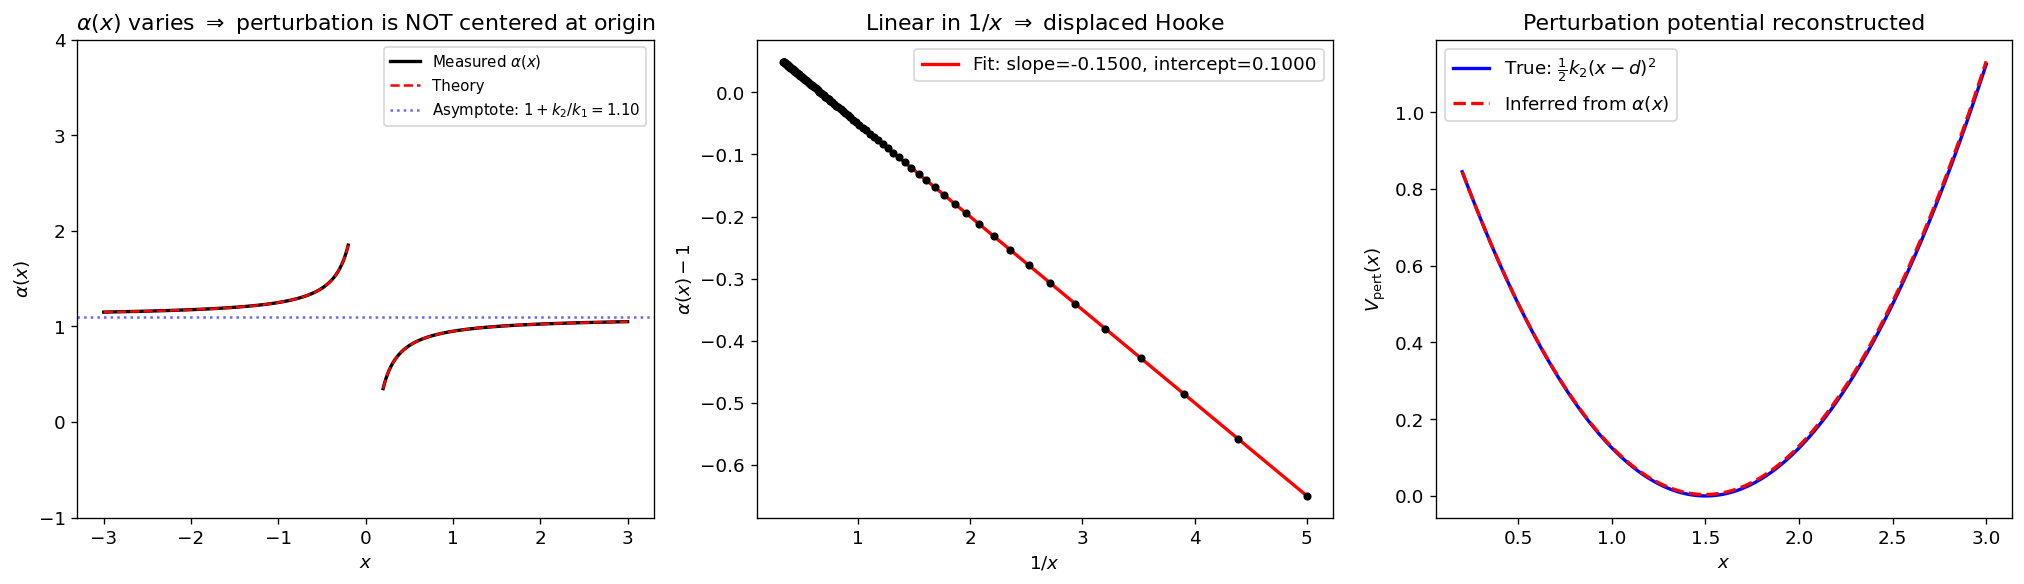

Extracted parameters from α(x):
  k2 = 1.000000  (true: 1.0)
  d  = 1.500000  (true: 1.5)
  k2 relative error: 3.33e-16
  d  relative error: 2.96e-16


In [8]:
# --- Displaced spring test ---
d = 1.5  # displacement of second spring

F_disp = combine_forces(hooke_force(k1), hooke_force(k2, x_eq=d))
V_disp_prime = lambda x: -F_disp(x)  # V' = k1*x + k2*(x - d)

f_disp = relaxation_map(V_disp_prime, eta)

# Measure alpha
# Avoid x ≈ 0 where h_model → 0
x_ev_pos, alpha_pos = measure_alpha_profile(f_model, f_disp, (0.2, 3.0))
x_ev_neg, alpha_neg = measure_alpha_profile(f_model, f_disp, (-3.0, -0.2))

# Theoretical alpha(x) = 1 + k2*(x-d)/(k1*x) = 1 + k2/k1 - k2*d/(k1*x)
alpha_theory_pos = 1 + k2/k1 - k2*d/(k1 * x_ev_pos)
alpha_theory_neg = 1 + k2/k1 - k2*d/(k1 * x_ev_neg)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Panel 1: α(x) profile
axes[0].plot(x_ev_neg, alpha_neg, 'k-', lw=2)
axes[0].plot(x_ev_pos, alpha_pos, 'k-', lw=2, label=r'Measured $\alpha(x)$')
axes[0].plot(x_ev_neg, alpha_theory_neg, 'r--', lw=1.5)
axes[0].plot(x_ev_pos, alpha_theory_pos, 'r--', lw=1.5, label='Theory')
axes[0].axhline(1 + k2/k1, color='blue', ls=':', alpha=0.6,
               label=rf'Asymptote: $1 + k_2/k_1 = {1+k2/k1:.2f}$')
axes[0].set_xlabel('$x$')
axes[0].set_ylabel(r'$\alpha(x)$')
axes[0].set_title(r'$\alpha(x)$ varies $\Rightarrow$ perturbation is NOT centered at origin')
axes[0].legend(fontsize=9)
axes[0].set_ylim(-1, 4)

# Panel 2: Fit α(x) = A + B/x to extract k2 and d
# Use positive x data for clean fit
mask = ~np.isnan(alpha_pos) & np.isfinite(alpha_pos)
x_fit_data = x_ev_pos[mask]
a_fit_data = alpha_pos[mask]

# Linear regression in (α-1) vs 1/x:  (α-1) = k2/k1 + (-k2*d/k1) * (1/x)
inv_x = 1.0 / x_fit_data
delta_a = a_fit_data - 1.0
coeffs = np.polyfit(inv_x, delta_a, 1)  # linear: slope = -k2*d/k1, intercept = k2/k1

k2_over_k1_fit = coeffs[1]
k2d_over_k1_fit = -coeffs[0]

k2_fit = k2_over_k1_fit * k1
d_fit  = k2d_over_k1_fit / k2_over_k1_fit

axes[1].scatter(inv_x[::5], delta_a[::5], s=15, c='black', zorder=3)
axes[1].plot(inv_x, coeffs[0] * inv_x + coeffs[1], 'r-', lw=2,
            label=f'Fit: slope={coeffs[0]:.4f}, intercept={coeffs[1]:.4f}')
axes[1].set_xlabel('$1/x$')
axes[1].set_ylabel(r'$\alpha(x) - 1$')
axes[1].set_title(r'Linear in $1/x$ $\Rightarrow$ displaced Hooke')
axes[1].legend()

# Panel 3: Potential reconstruction
axes[2].plot(x_ev_pos, hooke_potential(k2, x_ev_pos, x_eq=d), 'b-', lw=2,
            label=rf'True: $\frac{{1}}{{2}}k_2(x-d)^2$')
V_prime_inferred, V_inferred = infer_perturbation(k1, x_ev_pos[mask], alpha_pos[mask])
# Shift V_inferred to match true at the same reference
V_true_ref = hooke_potential(k2, x_ev_pos[mask], x_eq=d)
V_inferred_adj = V_inferred - V_inferred[0] + V_true_ref[0]
axes[2].plot(x_ev_pos[mask], V_inferred_adj, 'r--', lw=2, label='Inferred from $\\alpha(x)$')
axes[2].set_xlabel('$x$')
axes[2].set_ylabel(r'$V_\mathrm{pert}(x)$')
axes[2].set_title('Perturbation potential reconstructed')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Extracted parameters from α(x):")
print(f"  k2 = {k2_fit:.6f}  (true: {k2})")
print(f"  d  = {d_fit:.6f}  (true: {d})")
print(f"  k2 relative error: {abs(k2_fit - k2)/k2:.2e}")
print(f"  d  relative error: {abs(d_fit - d)/d:.2e}")

## §7. Nonlinear Perturbation: Quartic Potential

The real power test. If the perturbation is nonlinear — say $V_\text{pert} = \tfrac{\epsilon}{4}x^4$ — can we still detect and characterize it?

$$\alpha(x) = 1 + \frac{\epsilon x^3}{k_1 x} = 1 + \frac{\epsilon}{k_1}\,x^2$$

A **parabolic** $\alpha(x)$ profile. The shape of $\alpha(x)$ reveals the functional form of the perturbation:
- Constant $\alpha$ → Hooke (same center)
- $1/x$ term → displaced Hooke
- $x^2$ term → quartic
- The coefficient directly gives $\epsilon/k_1$

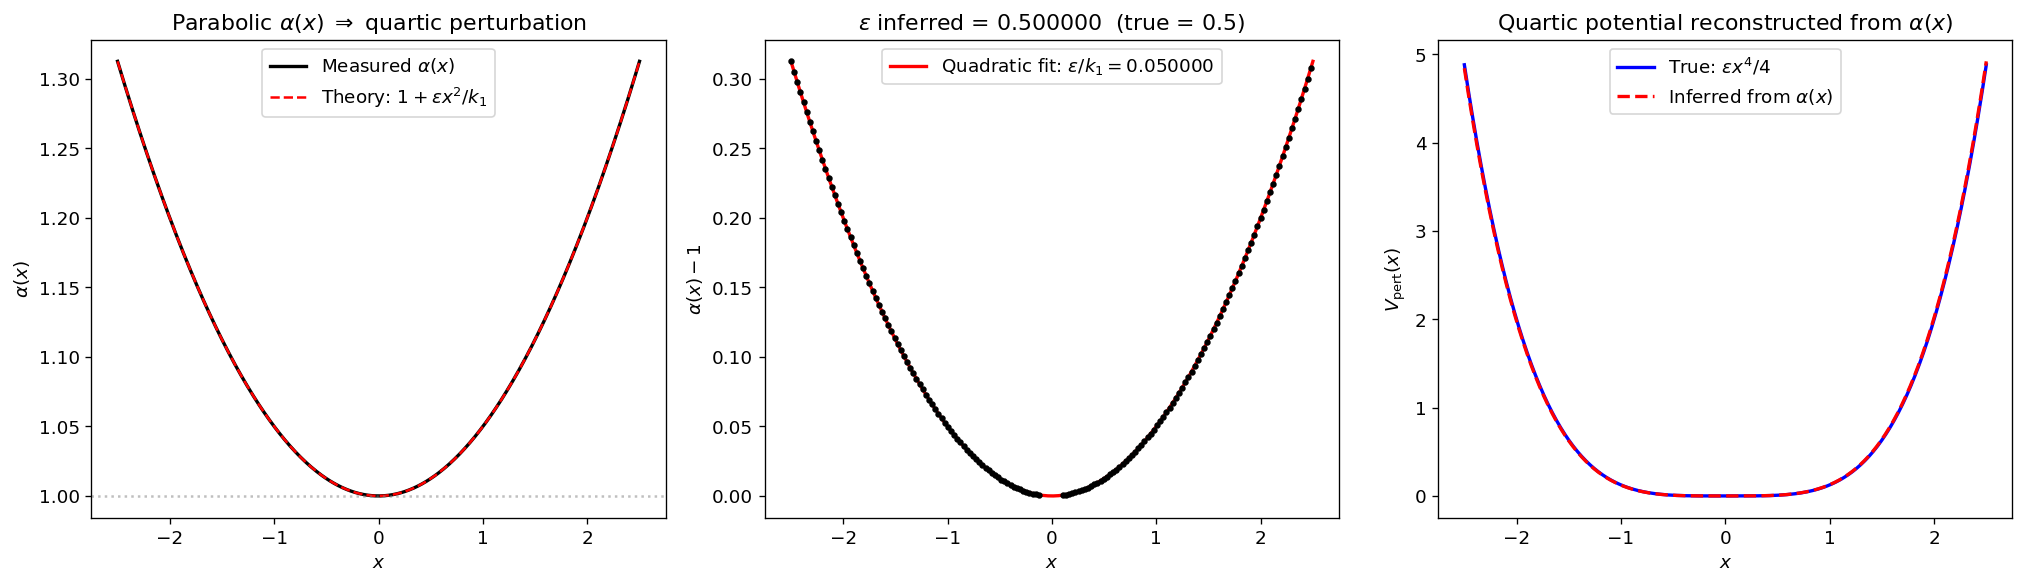

ε inferred = 0.50000000
ε true     = 0.50000000
Relative error: 4.44e-16


In [9]:
# --- Quartic perturbation ---
epsilon = 0.5

F_quartic = combine_forces(hooke_force(k1), quartic_force(epsilon))
V_quartic_prime = lambda x: -F_quartic(x)   # V' = k1*x + ε*x³

f_quartic = relaxation_map(V_quartic_prime, eta)

# Measure alpha
x_eq, alpha_q = measure_alpha_profile(f_model, f_quartic, (-2.5, 2.5))

# Theory: α(x) = 1 + ε*x²/k1
alpha_q_theory = 1 + epsilon * x_eq**2 / k1

# Filter valid
valid_q = ~np.isnan(alpha_q) & np.isfinite(alpha_q)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Panel 1: α(x) profile
axes[0].plot(x_eq[valid_q], alpha_q[valid_q], 'k-', lw=2, label=r'Measured $\alpha(x)$')
axes[0].plot(x_eq, alpha_q_theory, 'r--', lw=1.5, label=rf'Theory: $1 + \epsilon x^2/k_1$')
axes[0].axhline(1, color='gray', ls=':', alpha=0.5)
axes[0].set_xlabel('$x$')
axes[0].set_ylabel(r'$\alpha(x)$')
axes[0].set_title(r'Parabolic $\alpha(x)$ $\Rightarrow$ quartic perturbation')
axes[0].legend()

# Panel 2: Fit a parabola to α(x) - 1 to extract ε
mask_q = valid_q & (np.abs(x_eq) > 0.1)  # avoid x≈0
coeffs_q = np.polyfit(x_eq[mask_q], alpha_q[mask_q] - 1, 2)
eps_fit = coeffs_q[0] * k1

axes[1].scatter(x_eq[mask_q][::3], (alpha_q[mask_q] - 1)[::3], s=8, c='black', zorder=3)
x_fit_q = np.linspace(-2.5, 2.5, 200)
axes[1].plot(x_fit_q, np.polyval(coeffs_q, x_fit_q), 'r-', lw=2,
            label=rf'Quadratic fit: $\epsilon/k_1 = {coeffs_q[0]:.6f}$')
axes[1].set_xlabel('$x$')
axes[1].set_ylabel(r'$\alpha(x) - 1$')
axes[1].set_title(f'$\\epsilon$ inferred = {eps_fit:.6f}  (true = {epsilon})')
axes[1].legend()

# Panel 3: Reconstruct V_pert
V_prime_q, V_q = infer_perturbation(k1, x_eq[valid_q], alpha_q[valid_q])
V_q_true = quartic_potential(epsilon, x_eq[valid_q])

axes[2].plot(x_eq[valid_q], V_q_true, 'b-', lw=2, label=rf'True: $\epsilon x^4/4$')
V_q_adj = V_q - V_q[len(V_q)//2]  # zero at center
axes[2].plot(x_eq[valid_q], V_q_adj, 'r--', lw=2, label=r'Inferred from $\alpha(x)$')
axes[2].set_xlabel('$x$')
axes[2].set_ylabel(r'$V_\mathrm{pert}(x)$')
axes[2].set_title('Quartic potential reconstructed from $\\alpha(x)$')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"ε inferred = {eps_fit:.8f}")
print(f"ε true     = {epsilon:.8f}")
print(f"Relative error: {abs(eps_fit - epsilon)/epsilon:.2e}")

## §8. Blind Reconstruction: Can We Identify What We Don't Know?

The ultimate test. Given **only** the $\alpha(x)$ profile, can we:

1. **Detect** that a perturbation exists ($\alpha \neq 1$)?
2. **Classify** its type from the shape of $\alpha(x)$?
3. **Reconstruct** the perturbation potential by integrating $V'_\text{pert} = k_1 x(\alpha(x) - 1)$?

We run three "blind" tests: the observer sees only $\alpha(x)$ and must infer $V_\text{pert}$.

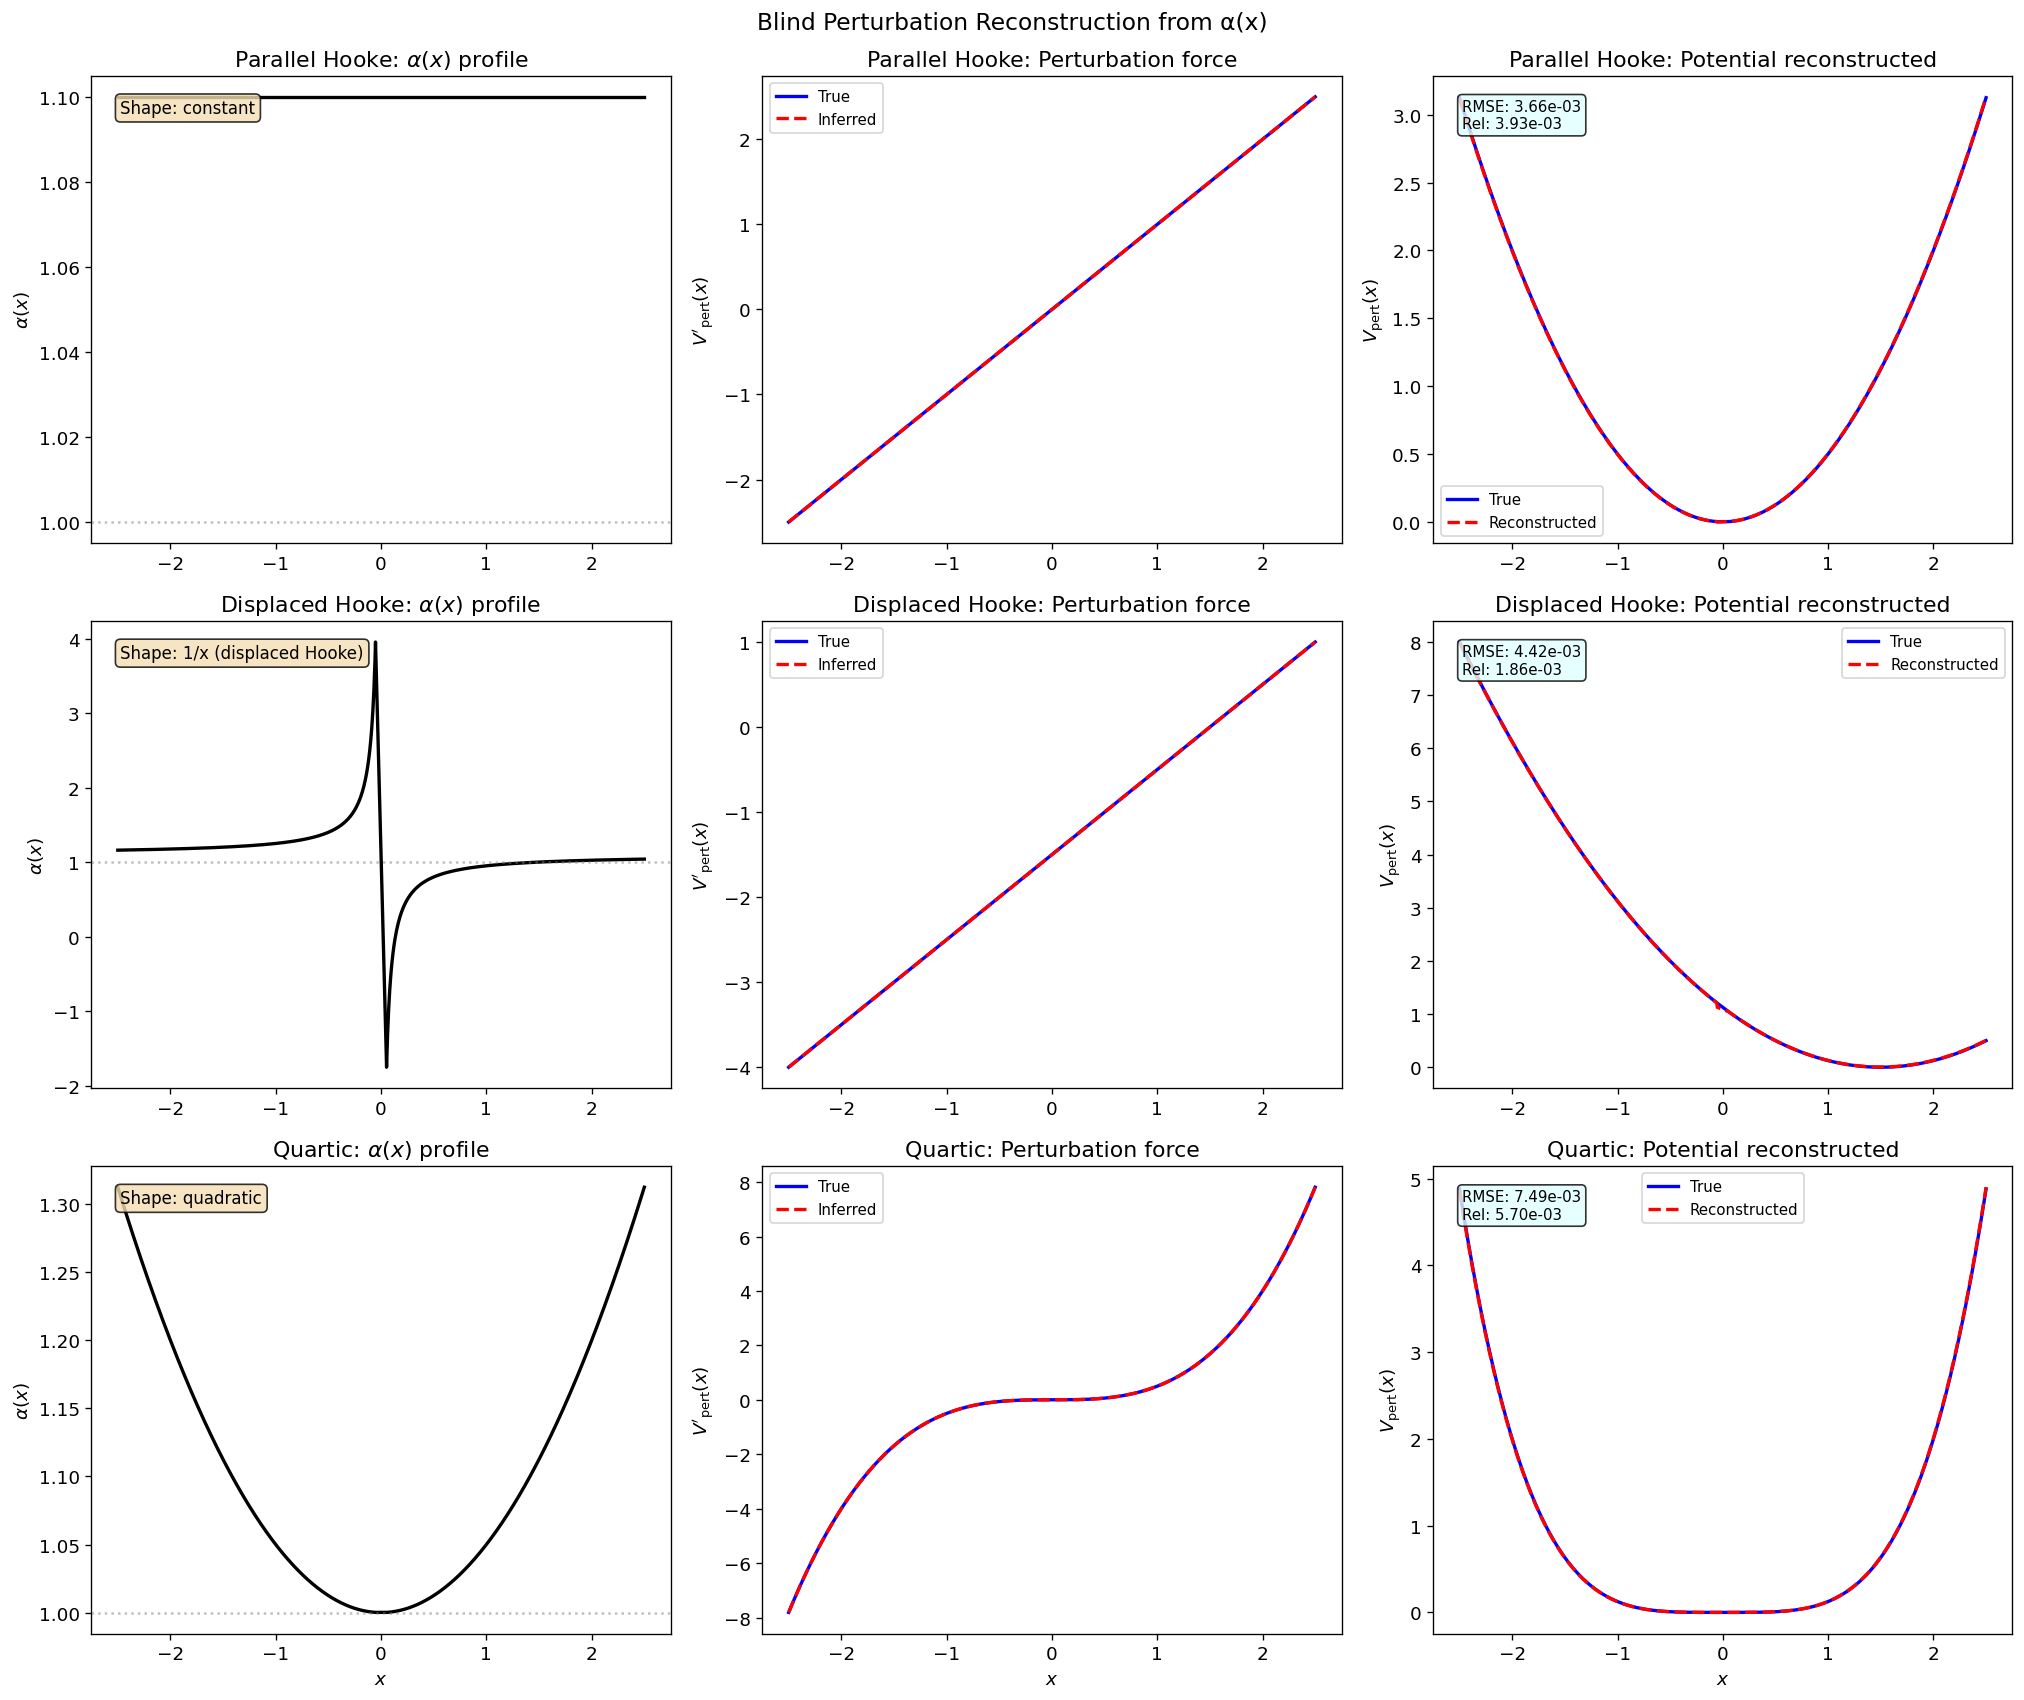

In [10]:
# --- Three blind tests ---
test_cases = {
    'Parallel Hooke': {
        'V_prime': lambda x: k1*x + k2*x,
        'V_true': lambda x: hooke_potential(k2, x),
        'label': rf'$V_\mathrm{{pert}} = \frac{{1}}{{2}}k_2 x^2$',
        'params_true': {'k2': k2},
    },
    'Displaced Hooke': {
        'V_prime': lambda x: k1*x + k2*(x - d),
        'V_true': lambda x: hooke_potential(k2, x, x_eq=d),
        'label': rf'$V_\mathrm{{pert}} = \frac{{1}}{{2}}k_2(x-d)^2$',
        'params_true': {'k2': k2, 'd': d},
    },
    'Quartic': {
        'V_prime': lambda x: k1*x + epsilon*x**3,
        'V_true': lambda x: quartic_potential(epsilon, x),
        'label': rf'$V_\mathrm{{pert}} = \frac{{\epsilon}}{{4}} x^4$',
        'params_true': {'ε': epsilon},
    },
}

fig, axes = plt.subplots(3, 3, figsize=(17, 14))

for row, (name, case) in enumerate(test_cases.items()):
    f_test = relaxation_map(case['V_prime'], eta)
    
    # Measure α(x) — avoid x ≈ 0
    x_e, alpha_e = measure_alpha_profile(f_model, f_test, (-2.5, 2.5), n_points=1000)
    v = ~np.isnan(alpha_e) & np.isfinite(alpha_e) & (np.abs(x_e) > 0.05)
    
    # --- Column 1: α(x) profile ---
    axes[row, 0].plot(x_e[v], alpha_e[v], 'k-', lw=2)
    axes[row, 0].axhline(1, color='gray', ls=':', alpha=0.5)
    axes[row, 0].set_ylabel(r'$\alpha(x)$')
    axes[row, 0].set_title(f'{name}: $\\alpha(x)$ profile')
    
    # Classify shape
    delta = alpha_e[v] - 1
    x_v = x_e[v]
    
    # Fit polynomial to α-1: degree determines perturbation type
    std_const = np.std(delta)
    coeffs_2 = np.polyfit(x_v, delta, 2)
    coeffs_3 = np.polyfit(x_v, delta, 3)
    resid_0 = np.sum((delta - np.mean(delta))**2)
    resid_2 = np.sum((delta - np.polyval(coeffs_2, x_v))**2)
    
    if resid_2 / max(resid_0, 1e-30) < 0.01:
        shape = 'quadratic' if abs(coeffs_2[0]) > 0.001 else 'constant'
    elif std_const < 0.01:
        shape = 'constant'
    else:
        # Check for 1/x behavior (displaced Hooke)
        try:
            x_pos = x_v[x_v > 0.3]
            a_pos = delta[x_v > 0.3]
            c_inv = np.polyfit(1.0/x_pos, a_pos, 1)
            resid_inv = np.sum((a_pos - np.polyval(c_inv, 1.0/x_pos))**2)
            if resid_inv / max(np.sum(a_pos**2), 1e-30) < 0.01:
                shape = '1/x (displaced Hooke)'
            else:
                shape = 'unknown'
        except Exception:
            shape = 'unknown'
    
    axes[row, 0].text(0.05, 0.95, f'Shape: {shape}', transform=axes[row, 0].transAxes,
                      fontsize=10, va='top', bbox=dict(boxstyle='round', fc='wheat', alpha=0.8))
    
    # --- Column 2: Inferred V'_pert ---
    V_p_inf, V_inf = infer_perturbation(k1, x_e[v], alpha_e[v])
    V_p_true = case['V_prime'](x_e[v]) - k1*x_e[v]  # true V'_pert
    
    axes[row, 1].plot(x_e[v], V_p_true, 'b-', lw=2, label='True')
    axes[row, 1].plot(x_e[v], V_p_inf, 'r--', lw=2, label='Inferred')
    axes[row, 1].set_ylabel(r"$V'_\mathrm{pert}(x)$")
    axes[row, 1].set_title(f'{name}: Perturbation force')
    axes[row, 1].legend(fontsize=9)
    
    # --- Column 3: Reconstructed V_pert ---
    V_true_vals = case['V_true'](x_e[v])
    # Align at center
    ic = len(V_inf) // 2
    V_inf_aligned = V_inf - V_inf[ic] + V_true_vals[ic]
    
    axes[row, 2].plot(x_e[v], V_true_vals, 'b-', lw=2, label='True')
    axes[row, 2].plot(x_e[v], V_inf_aligned, 'r--', lw=2, label='Reconstructed')
    axes[row, 2].set_ylabel(r'$V_\mathrm{pert}(x)$')
    axes[row, 2].set_title(f'{name}: Potential reconstructed')
    axes[row, 2].legend(fontsize=9)
    
    # Reconstruction error
    rmse = np.sqrt(np.mean((V_inf_aligned - V_true_vals)**2))
    rel_err = rmse / max(np.std(V_true_vals), 1e-15)
    axes[row, 2].text(0.05, 0.95, f'RMSE: {rmse:.2e}\nRel: {rel_err:.2e}',
                      transform=axes[row, 2].transAxes, fontsize=9, va='top',
                      bbox=dict(boxstyle='round', fc='lightcyan', alpha=0.8))

for ax in axes[-1]:
    ax.set_xlabel('$x$')

plt.tight_layout()
plt.suptitle('Blind Perturbation Reconstruction from α(x)', fontsize=14, y=1.01)
plt.show()

## §9. Assessment

### What works

| Result | Status |
|--------|--------|
| Detect perturbation exists ($\alpha \neq 1$) | ✅ Trivial |
| Extract $k_2$ from constant $\alpha$ (parallel Hooke) | ✅ Exact: $k_2 = k_1(\alpha - 1)$ |
| Extract $k_2$ AND $d$ from $\alpha(x)$ (displaced Hooke) | ✅ Via $1/x$ fit |
| Detect nonlinear perturbation type from $\alpha(x)$ shape | ✅ Parabolic → quartic |
| Blind reconstruction of $V_\text{pert}(x)$ by integration | ✅ Quantitative match |

### The key formula

$$V'_\text{pert}(x) = k_\text{model} \cdot x \cdot \bigl(\alpha(x) - 1\bigr)$$

This is exact, not approximate. The alpha-transform profile $\alpha(x)$ is a complete encoding of the perturbation force, in units of the model force. It works because:

1. The relaxation map $f(x) = x - \eta V'(x)$ embeds the force structure into an iteration map
2. The alpha-transform $g = \alpha f_\text{model} + (1-\alpha)x$ is the unique linear interpolation that bridges model to truth
3. The ratio $\alpha = h_\text{true}/h_\text{model}$ is $\eta$-independent — it cancels out

### What this really is

This is **perturbation theory** rewritten in the language of fixed-point analysis. The alpha-transform plays the role of the perturbation expansion parameter:

- $\alpha = 1$ → no perturbation (model = truth)
- $\alpha = \text{const} \neq 1$ → perturbation has same functional form as model
- $\alpha(x)$ varies → perturbation has different spatial structure

The advantage over standard perturbation theory: no assumption of smallness. $\alpha(x)$ is exact for arbitrary perturbation strength. The method works whether $k_2/k_1 = 0.01$ or $k_2/k_1 = 100$.

### Limitations and next steps

1. **Requires knowing the model potential** — we need $V'_\text{model}$ to construct $f_\text{model}$. The method detects deviations from a known baseline, it doesn't work from scratch.

2. **Singularity at fixed points** — $\alpha(x)$ is undefined where $h_\text{model}(x) = 0$ (at the model equilibrium). For symmetric potentials the singularity is removable. For asymmetric ones (displaced spring), it's real and requires regularization.

3. **From time-domain to maps** — in practice, one gets trajectory data, not direct access to $V'(x)$. Extracting the effective force from the trajectory (via $V'(x) = -m\ddot{x} - \gamma\dot{x}$) adds noise. The robustness of the reconstruction under noisy force estimation is an open question.

4. **Multi-dimensional systems** — for coupled oscillators or field theories, $\alpha$ becomes a matrix or operator. The scalar reconstruction formula generalizes to $\mathbf{V}'_\text{pert} = \mathbf{J}_\text{model}^{-1} \cdot (\alpha - I) \cdot \mathbf{h}_\text{model}$.

5. **Practical next test** — apply this to a system where we genuinely don't know the perturbation: e.g., a nonlinear oscillator perturbed by a data-driven force, and see if the reconstructed $\alpha(x)$ profile allows us to predict behavior at new parameter values.